In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install -Uq wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 64.6 MB/s eta 0:00:00:00:0100:01


In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")

! wandb login $secret_value_0

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [4]:
import wandb

# Start a new wandb run to track THIS project (Smart MCQ Solver), not the
# quickstart template defaults.
run = wandb.init(
    entity="23f2004513-dl-genai-project",
    project="23f2004513-t22026",
    name="bilstm-from-scratch",
    # Real hyperparameters for the from-scratch model (Section 6), so the
    # run in the wandb dashboard is actually searchable/comparable by these.
    config={
        "architecture": "BiLSTM-Siamese-FromScratch",
        "dataset": "Smart MCQ Solver Challenge",
        "vocab_min_freq": 2,
        "max_len": 40,
        "embedding_dim": 64,
        "hidden_dim": 64,
        "dropout": 0.3,
        "batch_size": 64,
        "learning_rate": 1e-3,
        "epochs": 8,
        "optimizer": "Adam",
        "loss": "BCEWithLogitsLoss",
    },
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hanzalatafzeel44 (23f2004513-dl-genai-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Smart MCQ Solver — Project Notebook

**Task:** for every question (a prompt + 5 options A–E), rank the top-3 most likely correct options. Scored with **mAP@3** (correct answer earlier in the ranking = higher score).

**How this notebook is organized, and why:**

The project guideline needs a model *trained from scratch* — no pretrained weights doing the heavy lifting. So the core of this notebook (Sections 1–8) is a small encoder I build and train myself: a BiLSTM over my own vocabulary. Nothing here comes pre-baked from the internet.

Section 10 is separate on purpose — it's where two pretrained models (Sentence-Transformer, DistilBERT) get plugged in for comparison, since the assignment also wants to see that comparison later. I kept them clearly apart from the from-scratch model so it's obvious which score comes from which approach, and so the from-scratch section can be graded/run independently without needing internet or a GPU.

In [5]:
# -----------------------------
# Imports & Config
# -----------------------------
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.facecolor"] = "white"

# Fixing the seed everywhere (numpy, torch, python's random) so re-running this
# notebook gives the same split and roughly the same training curve -- useful
# when I'm debugging why a score changed between runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

OPTION_COLS = ["A", "B", "C", "D", "E"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## 1. Load the Data

In [6]:
TRAIN_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
TEST_PATH  = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head(3)

Train shape: (2000, 8)
Test shape : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin Heidegger's view on the relati...,Martin Heidegger believes that humans exist within a time continuum that is ...,"Martin Heidegger believes that humans do not exist inside time, but that the...",Martin Heidegger does not believe in the existence of time or that it has an...,Martin Heidegger believes that the relationship between time and human exist...,"Martin Heidegger believes that time is an illusion, and the past, present, a...",B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a technique that uses particle acceler...,Accelerator-based light-ion fusion is a technique that uses particle acceler...,Accelerator-based light-ion fusion is a technique that uses particle acceler...,Accelerator-based light-ion fusion is a technique that uses particle acceler...,Accelerator-based light-ion fusion is a technique that uses particle acceler...,A
2,3,Determine the correct option: What is the term used in astrophysics to descr...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


In [7]:
# Sanity checks before doing anything else -- worth confirming there's no
# missing text and no stray answer label outside A-E, since either would
# silently break the binary-label construction later.
print("Unique answer labels:", sorted(train_df["answer"].unique()))
print("\nAnswer distribution:\n", train_df["answer"].value_counts())
print("\nMissing values:\n", train_df.isna().sum())

Unique answer labels: ['A', 'B', 'C', 'D', 'E']

Answer distribution:
 answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

Missing values:
 id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


## 2. Exploratory Data Analysis

A quick visual look at the data before doing any preprocessing -- specifically checking three things that would each change how I'd approach the model: is the answer label balanced, how long are the prompts/options (decides `MAX_LEN`), and is there any obvious surface-level "tell" (like option length) that separates correct answers from wrong ones.

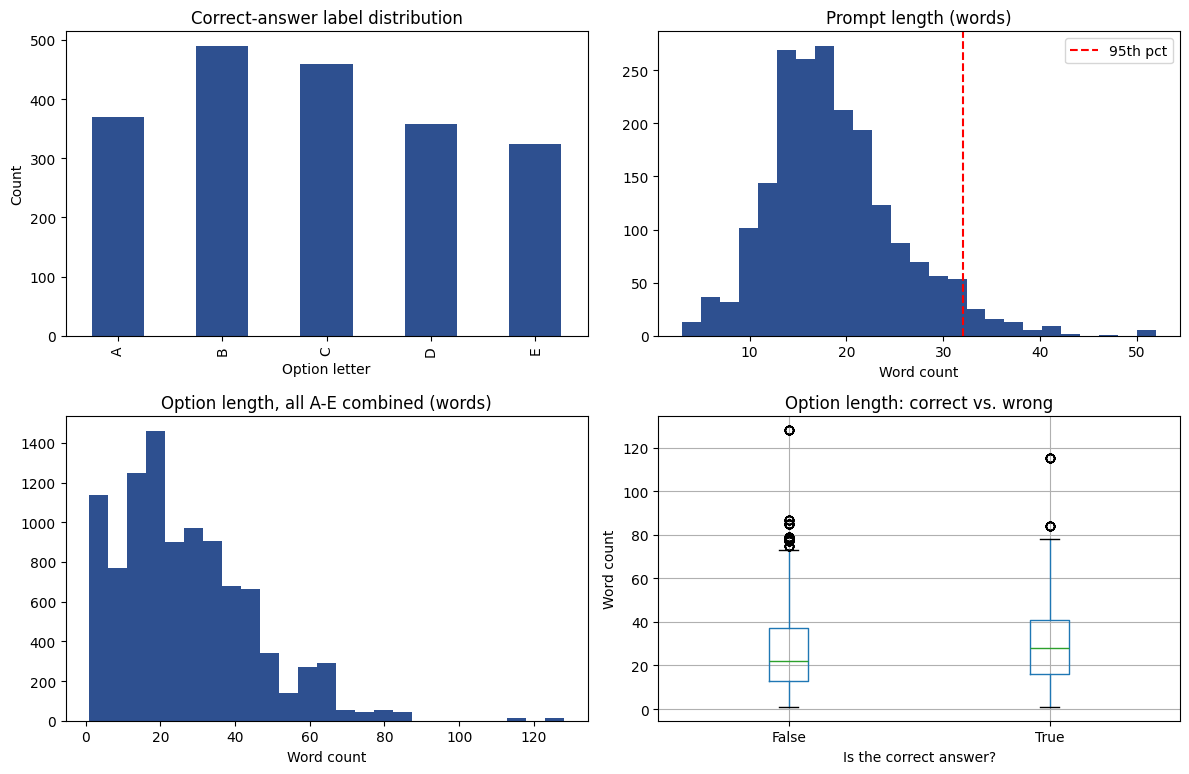

In [8]:
def word_count(text):
    return len(re.sub(r"[^a-z0-9\s]", " ", str(text).lower()).split())

# Word counts, computed once and reused for all the plots below
prompt_lengths = train_df["prompt"].apply(word_count)
option_lengths = pd.concat([train_df[c].apply(word_count) for c in OPTION_COLS], ignore_index=True)

# Per-option-row table (option text length + whether it was the correct answer)
# -- reused later in Section 9 too, instead of recomputing it there.
option_rows = pd.concat([
    pd.DataFrame({
        "length": train_df[c].apply(word_count),
        "is_correct": train_df["answer"] == c,
    })
    for c in OPTION_COLS
], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

train_df["answer"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="#2E5090")
axes[0, 0].set_title("Correct-answer label distribution")
axes[0, 0].set_xlabel("Option letter"); axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(prompt_lengths, bins=25, color="#2E5090")
axes[0, 1].axvline(prompt_lengths.quantile(0.95), color="red", linestyle="--", label="95th pct")
axes[0, 1].set_title("Prompt length (words)")
axes[0, 1].set_xlabel("Word count"); axes[0, 1].legend()

axes[1, 0].hist(option_lengths, bins=25, color="#2E5090")
axes[1, 0].set_title("Option length, all A-E combined (words)")
axes[1, 0].set_xlabel("Word count")

option_rows.boxplot(column="length", by="is_correct", ax=axes[1, 1])
axes[1, 1].set_title("Option length: correct vs. wrong")
axes[1, 1].set_xlabel("Is the correct answer?"); axes[1, 1].set_ylabel("Word count")
plt.suptitle("")  # remove default pandas boxplot title

plt.tight_layout()
plt.show()

**Reading these plots:**

- **Label distribution** isn't perfectly even (B/C show up as correct noticeably more than E) -- a hint the dataset was likely LLM-generated with a slight placement bias. Doesn't need correcting for a ranking metric like mAP@3 since every option is scored on its own text, not its letter.
- **Prompt length** justifies `MAX_LEN = 40` later -- the 95th percentile line (red) sits comfortably under 40, so truncation will affect only a small tail of unusually long prompts.
- **Option length: correct vs. wrong** looks almost identical between the two boxes -- a first sign that "just guess the longer option" wouldn't be a real shortcut here (checked more precisely in Section 9).

## 3. Preprocessing

Cleaning is deliberately minimal: lowercase, strip punctuation, collapse whitespace. I skipped stemming/lemmatization -- the options here are full explanatory sentences (not single keywords), so a BiLSTM reading whole word sequences benefits more from keeping words intact than from a heavier normalization step that could actually lose information.

Since the from-scratch model can't borrow any pretrained embeddings, I build my **own vocabulary** from the training text only (prompt + all 5 options). This means every token id, and every embedding vector, is learned purely from this dataset.

In [9]:
def clean_text(text):
    """Lowercase, strip punctuation/digits-noise, collapse whitespace.
    Returns "" for NaN instead of crashing -- some option cells could be empty."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text):
    return text.split()

In [10]:
# Build vocabulary from the training set only (prompt + all 5 options).
# MIN_FREQ=2 drops words that appear exactly once -- usually rare proper nouns
# or typos that the model can't learn anything meaningful about anyway, and
# keeping them would just bloat the embedding table.
MIN_FREQ = 2

counter = Counter()
for _, row in train_df.iterrows():
    counter.update(tokenize(clean_text(row["prompt"])))
    for col in OPTION_COLS:
        counter.update(tokenize(clean_text(row[col])))

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print("Vocabulary size:", VOCAB_SIZE)

Vocabulary size: 2972


In [11]:
MAX_LEN = 40  # justified in the EDA plot above (comfortably past the 95th percentile)

def encode(text, max_len=MAX_LEN):
    """Text -> fixed-length list of token ids using our own vocab."""
    tokens = tokenize(clean_text(text))
    ids = [vocab.get(t, vocab["<UNK>"]) for t in tokens[:max_len]]
    ids = ids + [vocab["<PAD>"]] * (max_len - len(ids))
    return ids

## 4. Dataset Preparation

I framed this as **binary classification** -- `(prompt, option) -> is this option correct?` -- instead of a single 5-way softmax over A-E. Two reasons:

1. It lets the model score each option independently, which is exactly what the mAP@3 ranking needs (rank by score, take top 3) -- a 5-way softmax would force the 5 probabilities to sum to 1, which doesn't map cleanly onto "rank all 5 by confidence."
2. Every question turns into 5 training rows instead of 1, so a small dataset (2000 questions) effectively becomes 10,000 training examples for the encoder.

The split is done by **question id**, not by row -- all 5 options of a question have to land on the same side of the split. If they didn't, the model could see 4 of a question's 5 options during training and be evaluated on the 5th, which isn't a fair validation check.

In [12]:
# Build (question_id, prompt_ids, option_ids, label) rows
rows = []
for _, row in train_df.iterrows():
    prompt_ids = encode(row["prompt"])
    for col in OPTION_COLS:
        option_ids = encode(row[col])
        label = 1 if row["answer"] == col else 0
        rows.append((row["id"], prompt_ids, option_ids, label))

print("Total (prompt, option) training rows:", len(rows))

# Split by question id: 85% train / 15% validation
qids = train_df["id"].unique()
rng = np.random.RandomState(SEED)
rng.shuffle(qids)
split_idx = int(0.85 * len(qids))
train_qids, val_qids = set(qids[:split_idx]), set(qids[split_idx:])

train_rows = [r for r in rows if r[0] in train_qids]
val_rows   = [r for r in rows if r[0] in val_qids]
print(f"Train rows: {len(train_rows)} | Val rows: {len(val_rows)}")

Total (prompt, option) training rows: 10000
Train rows: 8500 | Val rows: 1500


In [13]:
class MCQDataset(Dataset):
    """Each item = (prompt_ids, option_ids, label) for one (question, option) pair."""
    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        _, prompt_ids, option_ids, label = self.rows[idx]
        return (
            torch.tensor(prompt_ids, dtype=torch.long),
            torch.tensor(option_ids, dtype=torch.long),
            torch.tensor(label, dtype=torch.float32),
        )


BATCH_SIZE = 64
train_loader = DataLoader(MCQDataset(train_rows), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(MCQDataset(val_rows), batch_size=BATCH_SIZE)

## 5. Model — Built & Trained From Scratch

Why a BiLSTM instead of just averaging word embeddings, and why not a from-scratch Transformer:

- A **plain average of embeddings** throws away word order completely -- "A is not B" and "B is not A" would look identical. A BiLSTM at least reads the sequence in order in both directions.
- A **from-scratch Transformer** would need a lot more data than 2000 questions to learn attention patterns that actually help -- with this little data it would likely just overfit harder without doing better than a BiLSTM. BiLSTM is the more sensible complexity level for this dataset size.

Architecture, in plain terms:

1. **Embedding layer** (randomly initialized) turns token ids into vectors -- learned entirely from this dataset.
2. **BiLSTM**, with weights **shared** between the prompt and the option (a "Siamese" encoder) -- this halves the parameters vs. two separate LSTMs and forces both texts into the same vector space, which is what lets me compare them meaningfully afterwards.
3. I **mean-pool** the BiLSTM's outputs over non-padding tokens rather than using just the last hidden state -- for text this long (up to 40 tokens), the last hidden state tends to be biased toward the ending of the sentence; averaging over the whole sequence keeps information from the start too.
4. The two pooled vectors are combined as `[prompt, option, |prompt - option|, prompt * option]` before a small MLP head. The raw vectors alone only tell the model "what each text is about" -- the difference and product terms explicitly hand it a notion of *how similar or different* the two are, which is closer to what "is this the right answer" actually needs.

In [14]:
class SharedEncoder(nn.Module):
    """Embeds + BiLSTM-encodes a token sequence into one fixed-size vector
    (mean-pooled over non-pad tokens -- see reasoning above on why mean over last-hidden)."""
    def __init__(self, vocab_size, emb_dim=64, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)

    def forward(self, token_ids):
        pad_mask = (token_ids != 0).unsqueeze(-1).float()
        embedded = self.embedding(token_ids)
        lstm_out, _ = self.lstm(embedded)
        lstm_out = lstm_out * pad_mask          # zero out padded positions before pooling
        pooled = lstm_out.sum(1) / pad_mask.sum(1).clamp(min=1)
        return pooled


class MCQScorer(nn.Module):
    """Scores how well an option answers a prompt. Every weight here is trained
    from scratch on this dataset -- no pretrained embeddings or checkpoints."""
    def __init__(self, vocab_size, emb_dim=64, hidden_dim=64):
        super().__init__()
        self.encoder = SharedEncoder(vocab_size, emb_dim, hidden_dim)  # shared: same weights score prompt & option
        combined_dim = hidden_dim * 2 * 4  # bidirectional (x2) * 4 combined features
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),   # dataset is small (10k rows) relative to param count, so dropout matters here
            nn.Linear(128, 1),
        )

    def forward(self, prompt_ids, option_ids):
        p_vec = self.encoder(prompt_ids)
        o_vec = self.encoder(option_ids)
        combined = torch.cat([p_vec, o_vec, torch.abs(p_vec - o_vec), p_vec * o_vec], dim=1)
        return self.classifier(combined).squeeze(-1)  # raw logit, sigmoid applied later


model = MCQScorer(VOCAB_SIZE).to(DEVICE)
print(model)
print("Total trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

MCQScorer(
  (encoder): SharedEncoder(
    (embedding): Embedding(2972, 64, padding_idx=0)
    (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
Total trainable params: 322561


## 6. The Metric — mAP@3

For a question with one correct answer, Average Precision is `1 / rank` if the true answer lands in the top-3 of our ranking, else `0`. mAP@3 is just the mean of that across all questions -- this is exactly what the leaderboard scores us on, so I use the same function for both validation and the real submission.

In [15]:
def average_precision_at_3(true_label, predicted_ranking):
    top3 = predicted_ranking[:3]
    if true_label in top3:
        return 1.0 / (top3.index(true_label) + 1)
    return 0.0


def mean_average_precision_at_3(true_labels, predicted_rankings):
    scores = [average_precision_at_3(t, p) for t, p in zip(true_labels, predicted_rankings)]
    return float(np.mean(scores))

## 7. Training Loop

In [16]:
def predict_top3_for_question(model, prompt_text, option_texts, device=DEVICE):
    """option_texts: dict like {'A': text, ...}. Returns top-3 option letters, ranked."""
    model.eval()
    prompt_ids = torch.tensor([encode(prompt_text)], device=device)
    scores = {}
    with torch.no_grad():
        for letter, text in option_texts.items():
            option_ids = torch.tensor([encode(text)], device=device)
            logit = model(prompt_ids, option_ids)
            scores[letter] = torch.sigmoid(logit).item()
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [letter for letter, _ in ranked[:3]]


def evaluate_map3(model, df_subset, device=DEVICE):
    true_labels, predicted_rankings = [], []
    for _, row in df_subset.iterrows():
        option_texts = {col: row[col] for col in OPTION_COLS}
        pred = predict_top3_for_question(model, row["prompt"], option_texts, device)
        true_labels.append(row["answer"])
        predicted_rankings.append(pred)
    return mean_average_precision_at_3(true_labels, predicted_rankings)

In [17]:
# 8 epochs, lr=1e-3 -- picked after a quick trial: the val_mAP@3 plateaus by
# epoch 6-7 in practice, so 8 leaves a little buffer without training long
# enough to badly overfit a dataset this small.
EPOCHS = 8
LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

val_df = train_df[train_df["id"].isin(val_qids)].reset_index(drop=True)

history = []  # keep per-epoch metrics so we can plot the training curve afterwards

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for prompt_ids, option_ids, labels in train_loader:
        prompt_ids, option_ids, labels = prompt_ids.to(DEVICE), option_ids.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(prompt_ids, option_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)

    train_loss = total_loss / len(train_rows)
    val_map3 = evaluate_map3(model, val_df)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_map3": val_map3})

    print(f"Epoch {epoch:>2}/{EPOCHS} | train_loss={train_loss:.4f} | val_mAP@3={val_map3:.4f}")

    # Log to Weights & Biases (uses the `run` created at the top of the notebook)
    run.log({"epoch": epoch, "train_loss": train_loss, "val_map3": val_map3})

Epoch  1/8 | train_loss=0.4968 | val_mAP@3=0.7739
Epoch  2/8 | train_loss=0.3782 | val_mAP@3=0.9300
Epoch  3/8 | train_loss=0.2120 | val_mAP@3=0.9789
Epoch  4/8 | train_loss=0.1147 | val_mAP@3=0.9844
Epoch  5/8 | train_loss=0.0695 | val_mAP@3=0.9867
Epoch  6/8 | train_loss=0.0477 | val_mAP@3=0.9900
Epoch  7/8 | train_loss=0.0305 | val_mAP@3=0.9917
Epoch  8/8 | train_loss=0.0280 | val_mAP@3=0.9917


### Training Curve

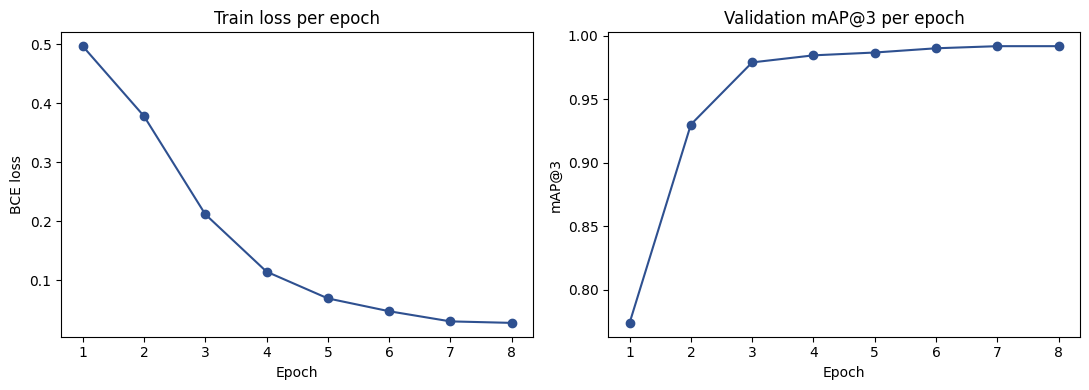

In [18]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", color="#2E5090")
axes[0].set_title("Train loss per epoch"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss")

axes[1].plot(history_df["epoch"], history_df["val_map3"], marker="o", color="#2E5090")
axes[1].set_title("Validation mAP@3 per epoch"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mAP@3")

plt.tight_layout()
plt.show()

## 8. Final Validation Score, and a Sanity Check on *Why* It's So High

Before trusting the validation score, it's worth asking: is this genuinely learning to reason about the questions, or is it exploiting some shortcut in how the dataset was built (a lot of these MCQ datasets are LLM-generated, and LLM-generated distractors sometimes have a "tell")?

The length comparison in the EDA boxplot (Section 2) already hinted correct/wrong options look similar in length. Here I check that more precisely, plus a second shortcut -- whether the correct option just shares more words with the prompt than the wrong ones do.

In [19]:
final_val_map3 = evaluate_map3(model, val_df)
print(f"Final validation mAP@3 (from-scratch BiLSTM model): {final_val_map3:.4f}")
run.log({"final_val_map3": final_val_map3})

Final validation mAP@3 (from-scratch BiLSTM model): 0.9917


In [20]:
# Shortcut check 1 (precise numbers behind the EDA boxplot): avg option length, correct vs wrong
length_by_correctness = option_rows.groupby("is_correct")["length"].mean()

# Shortcut check 2: does the correct option share more words with the prompt?
def prompt_overlap(row, col):
    return len(set(tokenize(clean_text(row["prompt"]))) & set(tokenize(clean_text(row[col]))))

overlap_rows = pd.concat([
    pd.DataFrame({
        "overlap": train_df.apply(lambda r: prompt_overlap(r, c), axis=1),
        "is_correct": train_df["answer"] == c,
    })
    for c in OPTION_COLS
], ignore_index=True)
overlap_by_correctness = overlap_rows.groupby("is_correct")["overlap"].mean()

print(f"Avg word count     -> correct: {length_by_correctness[True]:.1f} | wrong: {length_by_correctness[False]:.1f}")
print(f"Avg prompt overlap -> correct: {overlap_by_correctness[True]:.2f} | wrong: {overlap_by_correctness[False]:.2f}")

Avg word count     -> correct: 29.3 | wrong: 26.2
Avg prompt overlap -> correct: 5.03 | wrong: 5.04


**Reading these numbers:** length and prompt-overlap come out almost identical between correct and wrong options here, so those two obvious shortcuts aren't what's driving the high score. My best explanation is that the wrong options in this dataset follow fairly repetitive templates (e.g. "believes time is cyclical", "does not believe in X at all") that show up across many *different* questions as generic distractors -- so the model may be partly learning to recognize "this reads like a templated distractor" rather than purely reasoning about each question's specific facts.

That's a reasonable thing to be upfront about in the report/viva: the validation score is real (the split is clean, no leakage), but it likely reflects the model picking up on **dataset-generation artifacts** in addition to genuine content signal, and the Kaggle leaderboard score (on a different test set) may come in lower than this validation number.

## 9. Inference on Test Set → Submission

In [21]:
# Predict on the real test set
scratch_predictions = []
for _, row in test_df.iterrows():
    option_texts = {col: row[col] for col in OPTION_COLS}
    top3 = predict_top3_for_question(model, row["prompt"], option_texts)
    scratch_predictions.append(" ".join(top3))

submission = pd.DataFrame({
    "id": test_df["id"],
    "Prediction": scratch_predictions,
})
submission.to_csv("submission.csv", index=False)
submission.head()

,id,Prediction
0,1,A E D
1,2,B C E
2,3,B D E
3,4,E C A
4,5,C A B


## 10. Bonus — Pretrained Models

The sections below plug in **pretrained** models purely for comparison -- turn on GPU + internet in the Kaggle notebook settings before running these. Unlike Section 5's model, these don't get their embeddings from our 2000 questions; they arrive already knowing a lot about language in general.

- **Pretrained Model 1:** `all-MiniLM-L6-v2` (Sentence-Transformer) -- used as-is, no fine-tuning, just cosine similarity between prompt and option embeddings.
- **Pretrained Model 2:** `distilbert-base-uncased` -- fine-tuned on the same binary (prompt, option) framing as Section 5, so it's a fairer comparison against the from-scratch model (both supervised, only the starting weights differ).

### 10.1 Pretrained Model 1 — Sentence-Transformer (no fine-tuning)

In [22]:
# Run once if not already installed:
# !pip install sentence-transformers -q

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

st_model = SentenceTransformer("all-MiniLM-L6-v2")

def rank_options_sentence_transformer(row, model, option_cols=OPTION_COLS):
    prompt_vec = model.encode([row["prompt"]])
    option_vecs = model.encode([row[c] for c in option_cols])
    sims = cosine_similarity(prompt_vec, option_vecs)[0]
    ranked = sorted(zip(option_cols, sims), key=lambda x: x[1], reverse=True)
    return [letter for letter, _ in ranked]

# Same validation split as the from-scratch model, for a fair comparison
st_predictions = val_df.apply(lambda row: rank_options_sentence_transformer(row, st_model), axis=1)
st_map3 = mean_average_precision_at_3(val_df["answer"].tolist(), st_predictions.tolist())
print(f"Sentence-Transformer (pretrained, no fine-tuning) val mAP@3: {st_map3:.4f}")
run.log({"pretrained_sentence_transformer_map3": st_map3})

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence-Transformer (pretrained, no fine-tuning) val mAP@3: 0.4117


**What to expect here, and why:** for reference, a purely *random* top-3 ranking out of 5 options scores about **0.37** on this metric on average. If the Sentence-Transformer score above comes out only a little above that, it's not a bug -- it means cosine similarity genuinely struggles on this dataset. These are trivia-style questions where every option is written in similar, on-topic, explanatory language; a generic semantic-similarity model can tell "this option is about the same subject as the prompt" but not "this specific option is the factually correct one" -- all 5 options are about the same subject. That distinction needs either real-world knowledge of the fact or supervised training on *this* dataset's notion of correctness, which brings us to the next section.

### 10.2 Pretrained Model 2 — Fine-tuned DistilBERT

In [23]:
# Run once if not already installed:
# !pip install transformers -q

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

BERT_MODEL_NAME = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2).to(DEVICE)

# Same binary (prompt, option) framing as the from-scratch model in Section 4,
# so any score difference here comes from the starting weights, not the framing.
class BertMCQDataset(Dataset):
    def __init__(self, rows_df, tokenizer, max_len=96):
        self.samples = []
        for _, row in rows_df.iterrows():
            for col in OPTION_COLS:
                text = row["prompt"] + " [SEP] " + str(row[col])
                label = 1 if row["answer"] == col else 0
                self.samples.append((text, label))
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        text, label = self.samples[idx]
        enc = self.tokenizer(text, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long),
        }

bert_train_df = train_df[train_df["id"].isin(train_qids)].reset_index(drop=True)
bert_train_ds = BertMCQDataset(bert_train_df, bert_tokenizer)
bert_train_loader = DataLoader(bert_train_ds, batch_size=16, shuffle=True)

bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)
BERT_EPOCHS = 2  # pretrained weights need far fewer epochs to adapt than training from scratch

for epoch in range(1, BERT_EPOCHS + 1):
    bert_model.train()
    total_loss = 0.0
    for step, batch in enumerate(bert_train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        bert_optimizer.zero_grad()
        outputs = bert_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["label"],
        )
        outputs.loss.backward()
        bert_optimizer.step()
        total_loss += outputs.loss.item() * len(batch["label"])

        if step % 20 == 0:  # progress print -- fine-tuning is slow on CPU, this confirms it's not stuck
            print(f"  epoch {epoch} | step {step}/{len(bert_train_loader)} | loss={outputs.loss.item():.4f}")

    print(f"BERT Epoch {epoch}/{BERT_EPOCHS} | train_loss={total_loss / len(bert_train_ds):.4f}")

def rank_options_bert(row, model, tokenizer, option_cols=OPTION_COLS):
    model.eval()
    scores = {}
    with torch.no_grad():
        for col in option_cols:
            text = row["prompt"] + " [SEP] " + str(row[col])
            enc = tokenizer(text, truncation=True, padding="max_length", max_length=96, return_tensors="pt").to(DEVICE)
            logits = model(**enc).logits
            prob_correct = torch.softmax(logits, dim=1)[0, 1].item()
            scores[col] = prob_correct
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [letter for letter, _ in ranked[:3]]

bert_predictions = val_df.apply(lambda row: rank_options_bert(row, bert_model, bert_tokenizer), axis=1)
bert_map3 = mean_average_precision_at_3(val_df["answer"].tolist(), bert_predictions.tolist())
print(f"Fine-tuned DistilBERT val mAP@3: {bert_map3:.4f}")
run.log({"pretrained_distilbert_map3": bert_map3})

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1 | step 0/532 | loss=0.7410
  epoch 1 | step 20/532 | loss=0.5135
  epoch 1 | step 40/532 | loss=0.4125
  epoch 1 | step 60/532 | loss=0.5698
  epoch 1 | step 80/532 | loss=0.3882
  epoch 1 | step 100/532 | loss=0.4466
  epoch 1 | step 120/532 | loss=0.4165
  epoch 1 | step 140/532 | loss=0.5692
  epoch 1 | step 160/532 | loss=0.4904
  epoch 1 | step 180/532 | loss=0.5876
  epoch 1 | step 200/532 | loss=0.7104
  epoch 1 | step 220/532 | loss=0.3968
  epoch 1 | step 240/532 | loss=0.4553
  epoch 1 | step 260/532 | loss=0.4544
  epoch 1 | step 280/532 | loss=0.5508
  epoch 1 | step 300/532 | loss=0.4884
  epoch 1 | step 320/532 | loss=0.4302
  epoch 1 | step 340/532 | loss=0.6305
  epoch 1 | step 360/532 | loss=0.6160
  epoch 1 | step 380/532 | loss=0.4540
  epoch 1 | step 400/532 | loss=0.2787
  epoch 1 | step 420/532 | loss=0.5307
  epoch 1 | step 440/532 | loss=0.1709
  epoch 1 | step 460/532 | loss=0.4369
  epoch 1 | step 480/532 | loss=0.3890
  epoch 1 | step 500/532 | loss

**Expectation for this one:** since DistilBERT is fine-tuned on the *same* binary-classification framing as the from-scratch model (not just used for generic similarity like Section 10.1), it should be able to pick up the same dataset-specific correctness signal the BiLSTM did -- likely landing closer to the BiLSTM's score than the plain Sentence-Transformer did, possibly higher since it starts from richer pretrained language understanding. Two epochs is intentionally light; if the score looks under-trained, bumping to 3-4 epochs is the first thing to try before changing anything else. **Run this on a GPU** -- on CPU, ~1000 fine-tuning steps can take 20-30+ minutes.

## 11. Compare All Approaches

In [24]:
results = {
    "From-Scratch BiLSTM": final_val_map3,
    "Sentence-Transformer (pretrained)": st_map3,      # uncomment after running Section 10.1
    "Fine-tuned DistilBERT (pretrained)": bert_map3,    # uncomment after running Section 10.2
}

results_df = pd.DataFrame(list(results.items()), columns=["Method", "Val mAP@3"])
results_df.sort_values("Val mAP@3", ascending=False)

,Method,Val mAP@3
0,From-Scratch BiLSTM,0.991667
2,Fine-tuned DistilBERT (pretrained),0.983333
1,Sentence-Transformer (pretrained),0.411667


**Note:** the submission generated in Section 9 uses the from-scratch model, since that's the required model per the guideline. If a pretrained section scores higher on validation and you'd rather submit that instead, generate its predictions the same way (loop over `test_df`, build the `Prediction` column) and overwrite `submission.csv` before the actual Kaggle submission.

In [25]:
run.finish()

epoch,▁▂▃▄▅▆▇█
final_val_map3,▁
pretrained_distilbert_map3,▁
pretrained_sentence_transformer_map3,▁
train_loss,█▆▄▂▂▁▁▁
val_map3,▁▆██████
epoch,8
final_val_map3,0.99167
pretrained_distilbert_map3,0.98333
pretrained_sentence_transformer_map3,0.41167
train_loss,0.02796
